# Transboundary flood discovery: Storm Boris, September 2024

A worked example with the [`euroflood`](https://github.com/cisgroup/euroflood) package,
reproducing Section S1.1 (Fig. S1) of the EuroFlood paper. Storm Boris flooded much of Central
and Eastern Europe in September 2024. Here, one index query recovers its archive footprint
across nine countries, attributes the detected area to each, and then pulls native-resolution
depth and modelled hazard only where we need them, without ever collecting or harmonising
national flood maps.

## The event

Between **9 and 16 September 2024**, Storm Boris brought persistent frontal rainfall over the
**Odra, Morava, and upper Danube** basins, causing severe flooding across **Poland, Czechia,
Austria, Slovakia, and the downstream Danube states**.

It is a textbook *transboundary* episode, and that is what makes it hard to study: one
meteorological event affects many countries, yet flood records, impact data, and mapping
products are each compiled within national systems using different formats and spatial
reference systems. The question this notebook answers is whether a single `euroflood` query
can recover the geographically distributed archive footprint and attribute detected flood area
by country, without first harmonising national flood maps.

## The archive and the index

The observations come from the **CEMS-EFAS satellite-derived flood-depth maps**, the only
open, continental record of observed flood *depth*: roughly 3,280 dated events (2015 to 2024)
at 20 m, reconstructed from Sentinel-1 (Copernicus GFM extent, spatio-temporal clustering,
then FLEXTH depth). The archive is open but hard to query, several thousand GeoTIFFs in a flat
HTTP directory geolocated only by a single centroid in each filename, even though one file can
bundle flooded areas up to 2,870 km apart.

`euroflood` adds an **inverted raster index**: each approximately 90 m cell stores the
identifiers of every event that inundated it, so footprints and recurrence come from a
windowed read with no rasters downloaded. Access is two-stage:

- **Discover** with `floods(...)`, returning a `FloodFrame` (a `geopandas.GeoDataFrame`).
- **Extract** native 20 m depth with `download()`, and modelled return-period hazard with
  `hazard(...)`, only for what you select.

> Runs against `euroflood >= 0.2.0` with the `viz` extra, querying the published index
> (needs network on first use, or a locally mirrored index).

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from IPython.display import Markdown

import euroflood as ef

import _support as S

## 1. Discover

A single query over a box around Central and Eastern Europe returns every archived cluster
that started in September 2024 and whose footprint intersects the window. It reads a small
window of the index and downloads nothing.

In [2]:
cat = ef.floods(bbox=(8.0, 43.5, 24.0, 55.0), start="2024-09-01", end="2024-09-30")
cat

,collection,event_id,date,year,end_date,cluster_id,filename,download_url,area_km2,geometry
70,historic,1506465524,2024-09-23,2024,2024-09-30,210,WD_MERGE_2024-09-23---2024-09-30_duration_7_da...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,14.454,"POLYGON ((24 43.5, 24 55, 8 55, 8 43.5, 24 43.5))"
71,historic,2681670024,2024-09-23,2024,2024-11-11,367,WD_MERGE_2024-09-23---2024-11-11_duration_35_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,217.568,"POLYGON ((24 43.5, 24 55, 8 55, 8 43.5, 24 43.5))"
140,historic,772644797,2024-09-09,2024,2024-11-18,366,WD_MERGE_2024-09-09---2024-11-18_duration_49_d...,https://jeodpp.jrc.ec.europa.eu/ftp/jrc-openda...,1280.155,"POLYGON ((24 43.5, 24 55, 8 55, 8 43.5, 24 43.5))"


## 2. Pick the Storm Boris cluster

The query returns three clusters. Storm Boris is simply the largest, so we take it by mapped
area rather than hard-coding an identifier, and reconstruct its approximately 90 m footprint
with `.footprints()` (still index-only, no download).

In [3]:
boris = cat.nlargest(1, "area_km2").footprints()
boris[["event_id", "date", "end_date", "duration_days", "extent_km2"]]

,event_id,date,end_date,duration_days,extent_km2
0,772644797,2024-09-09,2024-11-18,70,1253.306


The cluster covers roughly **1,253 km<sup>2</sup>** over a **70-day** window (9 September to
18 November 2024). An archived event is a spatio-temporal cluster of observations, not
necessarily one hydrological flood, so this record combines the initial Boris flooding with
later autumn inundation along the wider Danube system. That temporal spread is exactly why we
inspect `date` and `end_date` before drawing conclusions.

## 3. See it: an interactive map, straight from the index

With the `viz` extra, a `FloodFrame` renders without any raster download.
`cat.explore(footprints=True, tiles="grayscale")` returns an interactive **folium** map on a
grey basemap, each cluster on its own toggleable layer. Pan and zoom along the Odra and the
Danube to follow the cross-border cascade from Poland down to the Balkans.

In [4]:
cat.explore(footprints=True, tiles="grayscale")

## 4. Attribute the detected area by country

Because a `FloodFrame` is a GeoDataFrame, country attribution is a single spatial overlay:
reproject the footprint to the equal-area ETRS89-LAEA system (EPSG:3035), intersect it with
GISCO NUTS level 0 boundaries (2021, 1:10 million), and sum area per country.

In [5]:
countries = (
    gpd.read_file(S.DATA / "gisco" / "nuts0_10m_2021.geojson")
    [["NUTS_ID", "NAME_LATN", "geometry"]]
    .rename(columns={"NUTS_ID": "cc", "NAME_LATN": "country"})
    .to_crs("EPSG:3035")
)
inter = gpd.overlay(boris.to_crs("EPSG:3035"), countries, how="intersection")
inter["area_km2"] = inter.geometry.area / 1e6
per_country = (
    inter.groupby("cc")["area_km2"].sum()
    .round(1).sort_values(ascending=False)
)
per_country = per_country[per_country > 0.5]
per_country.to_frame("area_km2")

,area_km2
cc,
PL,497.7
DE,297.5
CZ,125.3
HR,121.1
HU,95.1
AT,50.8
SK,27.1
RO,18.7
RS,17.3


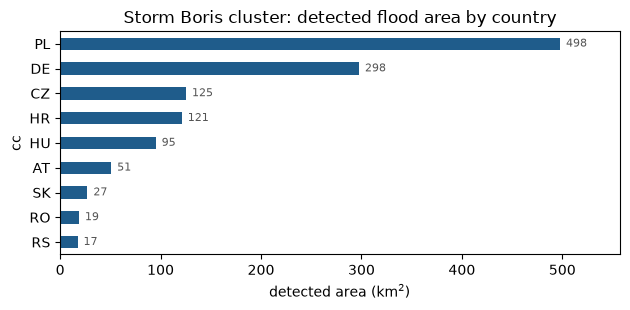

In [6]:
# The country breakdown as a bar chart (Table S2 as a figure).
ordered = per_country.sort_values()
fig, ax = plt.subplots(figsize=(6.4, 3.2))
ordered.plot.barh(ax=ax, color="#1f5c8b")
ax.set_xlabel("detected area (km$^2$)")
ax.set_title("Storm Boris cluster: detected flood area by country")
ax.margins(x=0.12)
for i, (cc, v) in enumerate(ordered.items()):
    ax.text(v + 6, i, f"{v:,.0f}", va="center", fontsize=8, color="#555555")
plt.tight_layout()
plt.show()

The result reproduces Table S2. The largest shares fall in **Poland** (along the Odra and Nysa
systems) and **Germany** (along the Elbe and lower Oder). The remaining area extends through
Czechia, Austria, Slovakia, Hungary, Croatia, Romania, and Serbia, forming a geographically
coherent sequence down the Danube. Once the footprint has been retrieved, this whole
attribution is a single spatial overlay against harmonised administrative boundaries.

In [7]:
# Key figures, computed from the results above.
area = float(boris["extent_km2"].iloc[0])
duration = int(boris["duration_days"].iloc[0])
top = per_country.head(2)
Markdown(
    f"### Key figures\n"
    f"| | |\n|---|---|\n"
    f"| **Detected flood area** | **{area:,.0f} km²** |\n"
    f"| **Countries** | **{len(per_country)}** |\n"
    f"| **Archive cluster** | **{duration} days** (9 Sep to 18 Nov 2024) |\n"
    f"| **Largest shares** | **{top.index[0]} {top.iloc[0]:,.0f} km²**, "
    f"**{top.index[1]} {top.iloc[1]:,.0f} km²** |\n"
)

### Key figures
| | |
|---|---|
| **Detected flood area** | **1,253 km²** |
| **Countries** | **9** |
| **Archive cluster** | **70 days** (9 Sep to 18 Nov 2024) |
| **Largest shares** | **PL 498 km²**, **DE 298 km²** |


## 5. Zoom in: native-resolution depth

Discovery is index-only; the 20 m source depth is fetched only where wanted. Two reaches of
the cluster tell the transboundary story, upstream at the border and downstream weeks later.

### The Oder at Schwedt (the German-Polish border)

Here the river itself forms the border, and the archive records inundation on both banks. We
take the same largest-area event, `download()` the ROI-cropped raster, and show it on the grey
basemap with `DepthRaster.explore()`.


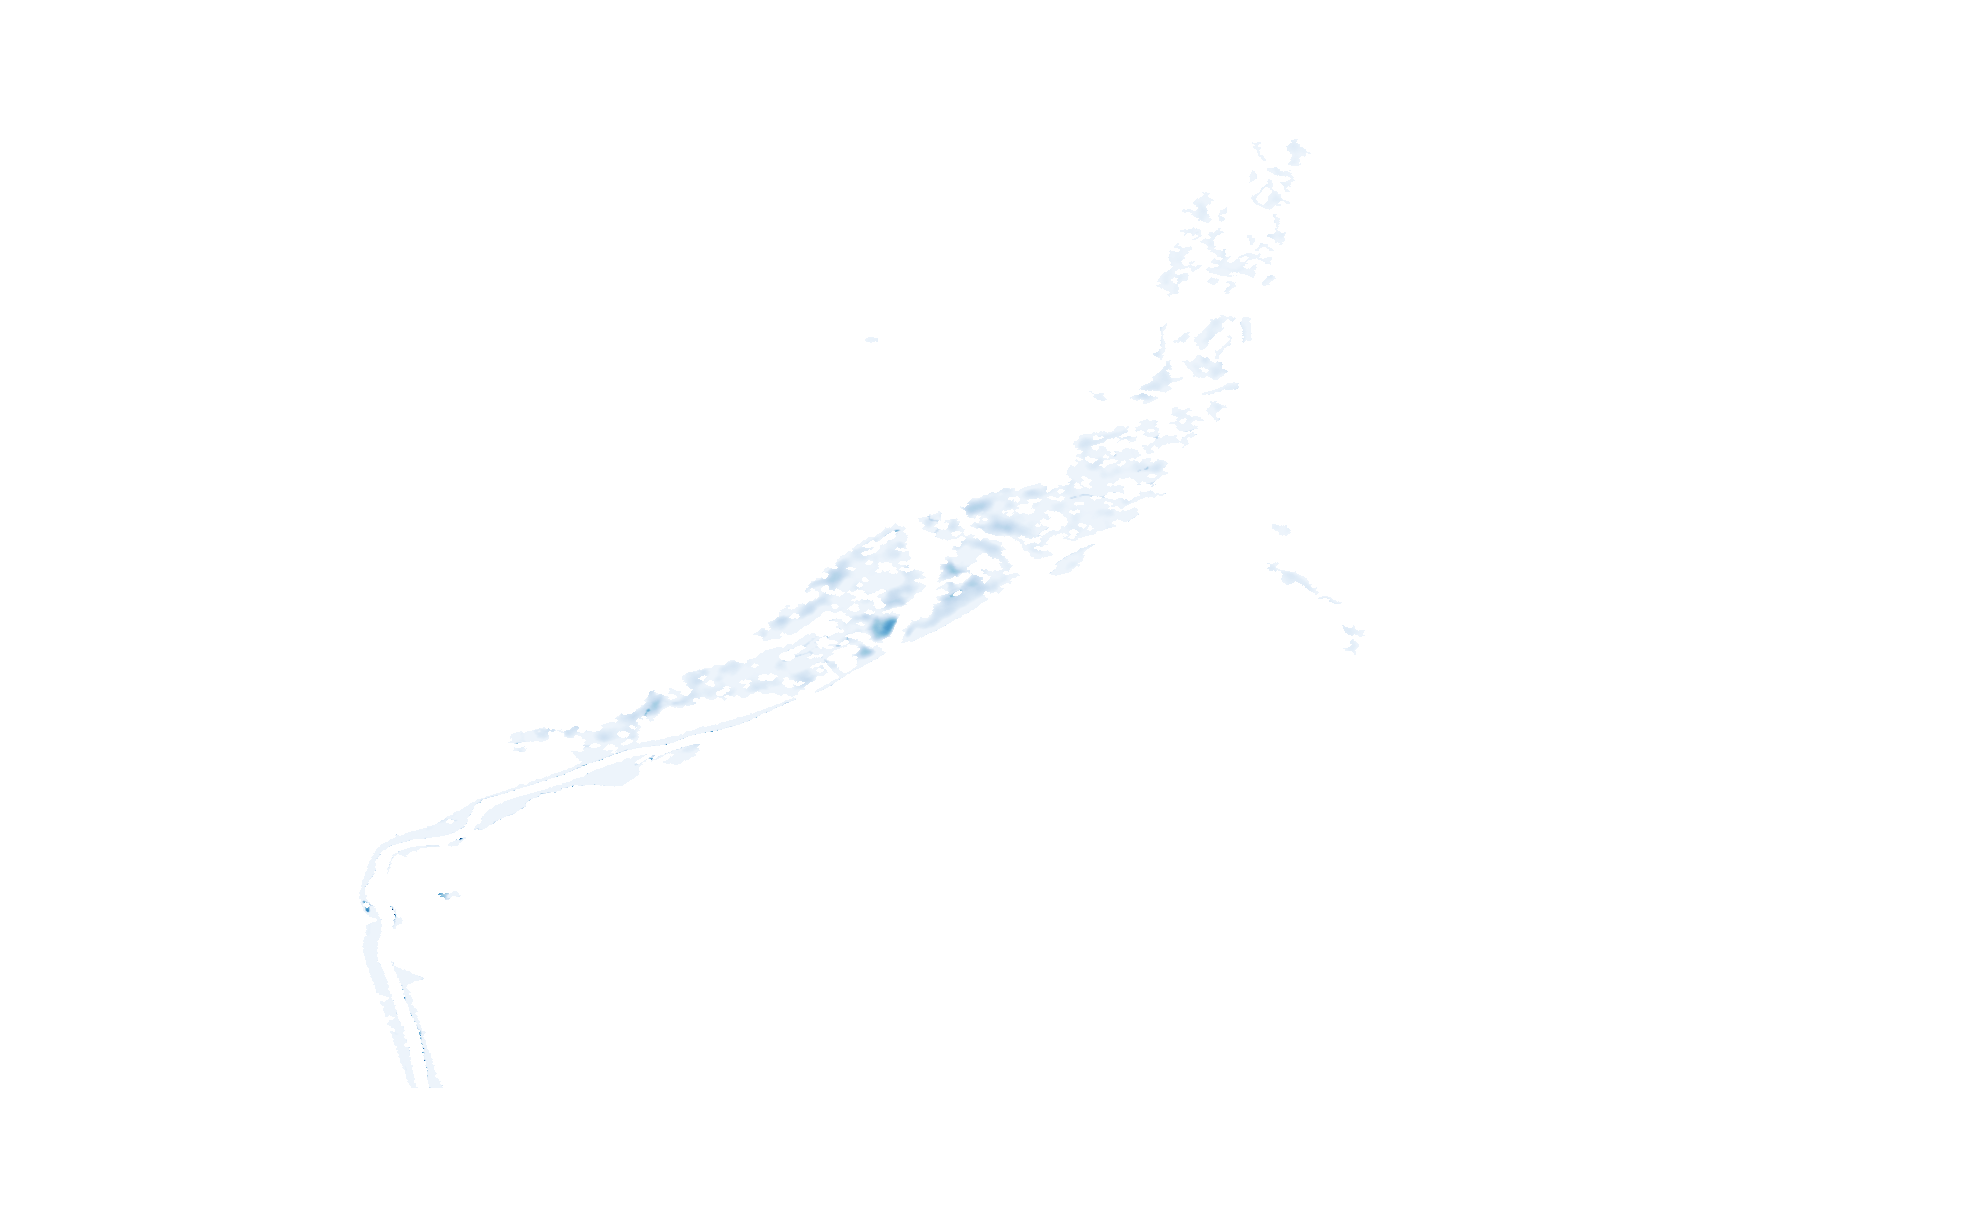

In [8]:
sel = ef.floods(bbox=(14.10, 52.90, 14.50, 53.15), start="2024-09-01", end="2024-09-30")
schwedt = ef.open_depth(ef.download(sel.nlargest(1, "area_km2"), str(S.ROOT / "out" / "boris_notebook"))[0])
schwedt.explore(tiles="grayscale", vmax=2.0)

### The Drava at Kopacki Rit, near Osijek (downstream, weeks later)

Part of the *same* archive cluster, this is the later downstream signal along the Danube
system in Croatia, hundreds of kilometres from Schwedt and separated in time. It is a concrete
reminder that one indexed event can span both the September peak and later autumn inundation.


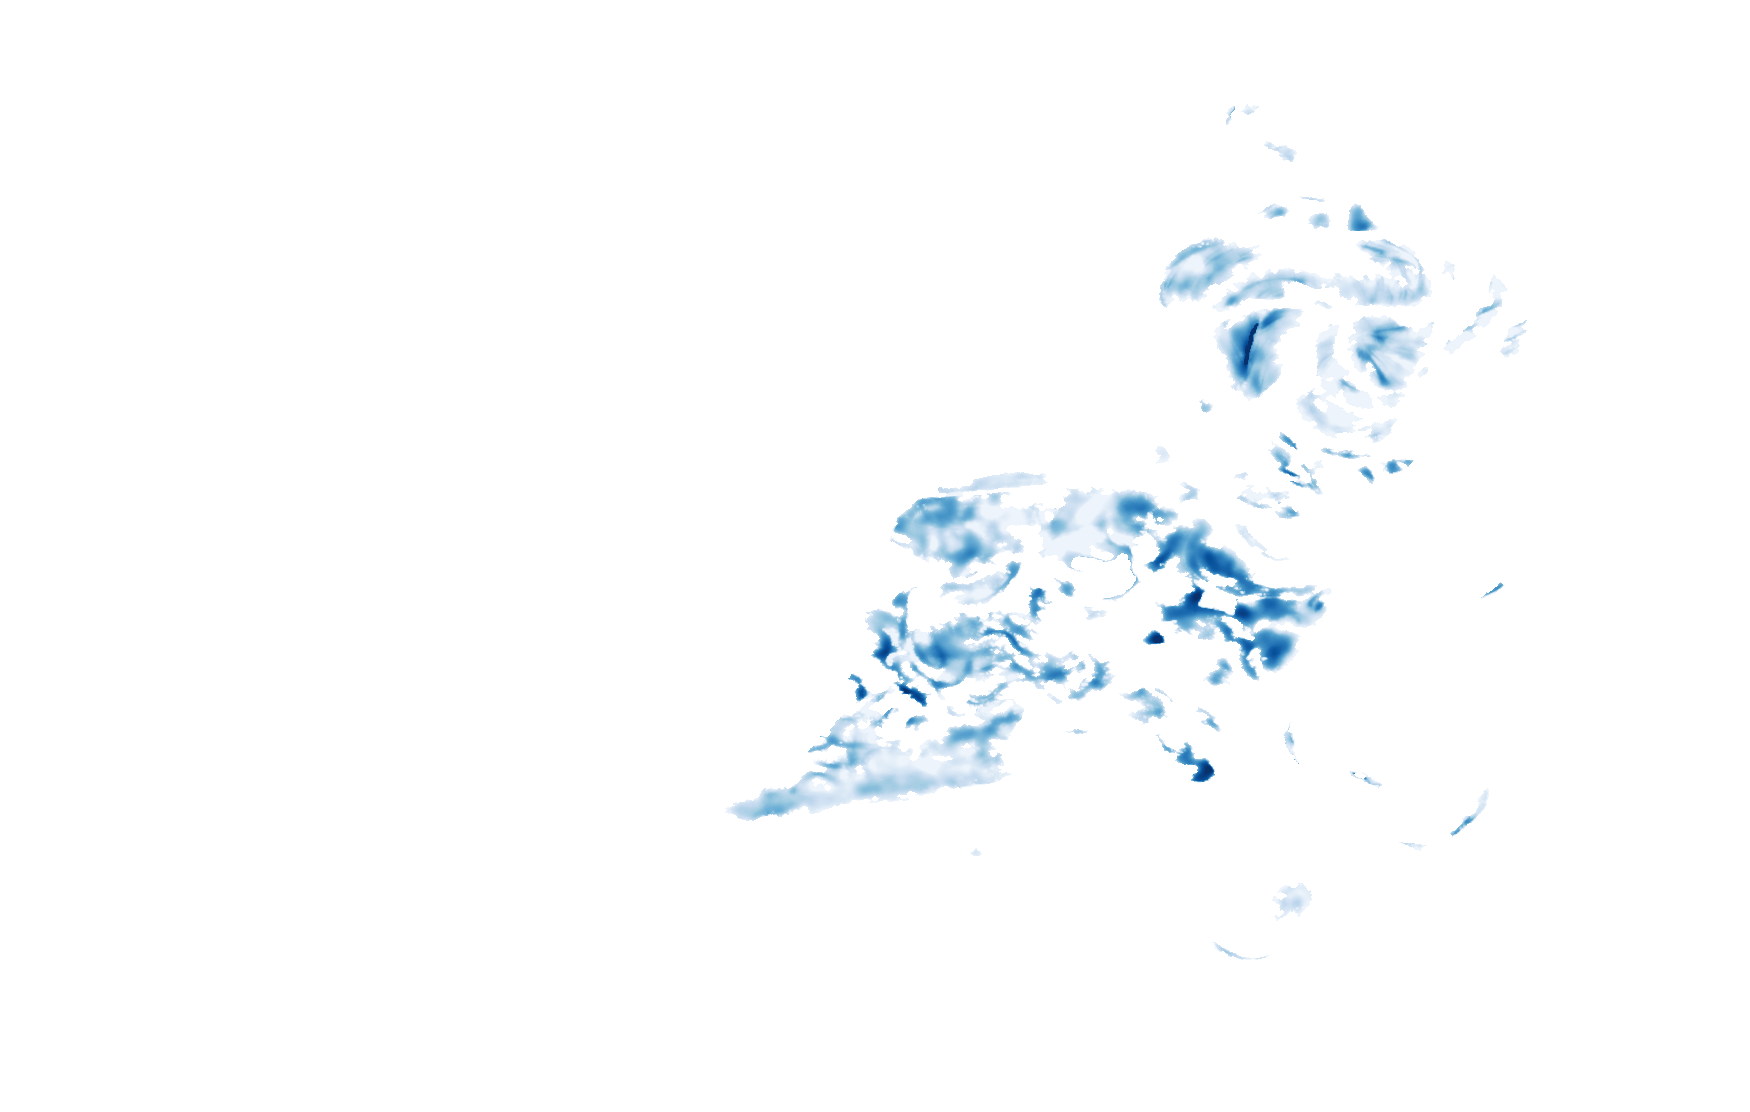

In [9]:
sel = ef.floods(bbox=(18.62, 45.50, 18.98, 45.72), start="2024-09-01", end="2024-09-30")
osijek = ef.open_depth(ef.download(sel.nlargest(1, "area_km2"), str(S.ROOT / "out" / "boris_notebook"))[0])
osijek.explore(tiles="grayscale", vmax=2.0)

## 6. Compare with modelled hazard

EuroFlood serves modelled river-flood hazard too (CEMS-GLOFAS return-period scenarios), so
observed and modelled extents live in one workflow. We retrieve the 10-year scenario for the
Schwedt reach and summarise its depth with `.stats()`.

In [10]:
haz = ef.hazard(bbox=(14.10, 52.90, 14.50, 53.15), return_period=10)
haz.download(str(S.ROOT / "out" / "boris_notebook"))
haz.stats()

,return_period,wet_pixels,max_depth_m,mean_depth_m,p95_depth_m,flooded_area_km2,volume_m3,volume_Mm3
0,10,21427,4.9,2.67,4.543,124.6478,332791423.2,332.7914


The modelled 10-year scenario is markedly deeper than the observed detected water above. That
is expected: the archive records what Sentinel-1 actually saw, often delayed, residual, and
shallow, so the observed depth is a lower bound rather than the modelled peak. Comparing the
two envelopes systematically is the subject of the Zutphen case study in the same paper.

## The published figure

The full multi-panel Fig. S1 (the country cascade, the Schwedt and Osijek depth chips, and the
summary) is assembled by the paper's figure script from the same query above, shown here for
comparison.

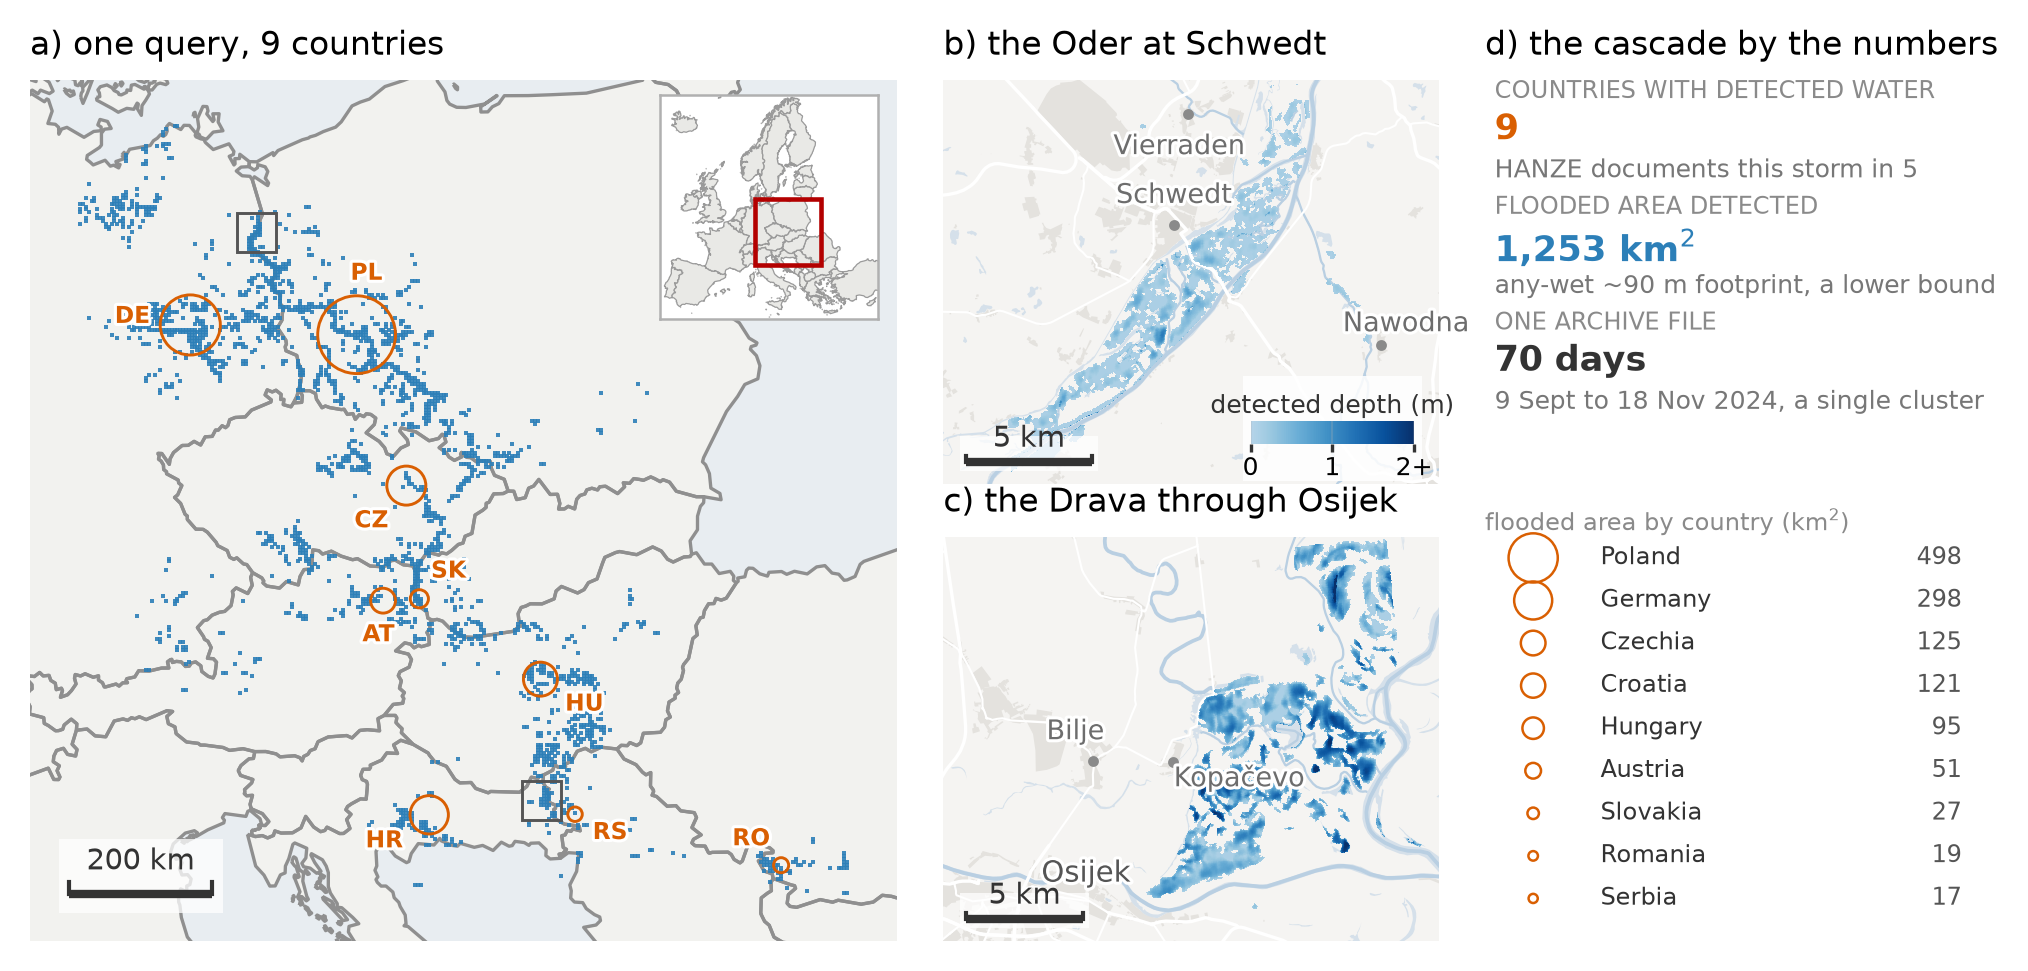

In [11]:
S.published_figure("boris")

## Interpretation

One index query retrieves a geographically distributed archive cluster and produces an
auditable country-level attribution, without collecting or harmonising national flood datasets
first. Three qualifications matter for reading the result:

1. **A cluster is not one flood.** The record is an archive-defined spatio-temporal cluster
   spanning 9 September to 18 November 2024 (70 days), so it combines the September peak with
   later autumn inundation along the wider Danube. Detected areas in downstream countries
   should not be read as the September peak alone; for physical event attribution, inspect the
   `date`/`end_date` fields and re-segment or aggregate accordingly.
2. **Date filters act on the cluster start date.** A narrow window such as 10 to 30 September
   would miss this record, whose start date is 9 September. Robust discovery uses a padded
   window and inspects the returned dates.
3. **Detected area is a lower bound.** The country areas inherit opposing biases: radar
   under-detection omits inundation that was not observed, while conservative resampling to the
   approximately 90 m grid enlarges the footprint (median inflation factor 1.49 relative to the
   native 20 m wet area). Detected area and recurrence are counts of archived detections, never
   a return period.

## References and reuse

This notebook reproduces the Storm Boris case study (Supplementary Material, Section S1.1,
Fig. S1) of:

> J. Hackl (2026). *EuroFlood: a Python library and queryable index for the CEMS
> satellite-derived flood-depth archive of Europe.*